# Model comparison, continuous score [0, 1].
 
Pipeline:
  1. Friedman omnibus test
  2. Post-hoc Nemenyi + Critical Difference diagram
  3. Pairwise permutation test (with BH correction)
  4. CI percentile bootstrap on pairwise differences
  5. Summary table and visualization

In [1]:
import sys
from pathlib import Path

# Add src/ to Python path for local module imports
sys.path.insert(0, str(Path.cwd().parent / "src"))
 
import numpy as np
from scipy import stats
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

import constants



In [ ]:
# ══════════════════════════════════════════════
# 1. DATI
# ══════════════════════════════════════════════
# scores: matrice (N, K) dove ogni colonna è un modello.

SPLIT = 'total'
#model_type = constants.RectalCancerStagingData
np.random.seed(25)

FIGURES_NAME = "zero_shot"
SAVE_FIG = True

compared_models = [
    #'Nano',
    #'Nano MMR (λ=1.0)',
    #'Nano MMR (λ=0.5)',
    #'Nano FT',
    #'Nano FT OS',
    #'Llama FT',
    #'Mini',
    'GPT 4.1',
    #'GPT 4.1 FT',
    'GPT 5.4',
    'Mistral Large 3',
    'Opus 4.6'
]

base_dir = Path.cwd().parent
scores = pd.read_csv(base_dir / 'data' / 'metrics' / 'scores.csv')
scores.rename(
    columns={
        constants.OPENAI_GPT_4_1_NANO: 'Nano',
        f'{constants.OPENAI_GPT_4_1_NANO}_few-shots': 'Nano MMR (λ=1.0)',
        f'{constants.OPENAI_GPT_4_1_NANO}_MMR': 'Nano MMR (λ=0.5)',
        constants.TUNED_GPT_4_1_NANO: 'Nano FT',
        constants.TUNED_GPT_4_1_NANO_OVERSAMPLE: 'Nano FT OS',
        constants.OPENAI_GPT_4_1_MINI: 'Mini',
        constants.OPENAI_GPT_4_1: 'GPT 4.1',
        constants.TUNED_GPT_4_1: 'GPT 4.1 FT',
        #constants.TUNED_GPT_4_1_OVERSAMPLING: 'gpt_4_1_tuned_oversampling',
        #f'few_shots_{constants.TUNED_GPT_4_1_OVERSAMPLING}': 'gpt_4_1_tuned_few_shots',
        #f'MMR_{constants.TUNED_GPT_4_1_OVERSAMPLING}': 'gpt_4_1_tuned_MMR',
        constants.OPENAI_GPT_5_4: 'GPT 5.4',
        constants.MISTRAL_LARGE_3: 'Mistral Large 3',
        constants.CLAUDE_OPUS_4_6: 'Opus 4.6',
        #f'few_shots_{constants.CLAUDE_OPUS_4_6}': 'opus_4_6_few_shots',
        #f'MMR_{constants.CLAUDE_OPUS_4_6}': 'opus_4_6_MMR'
        constants.LLAMA_3_2_3B_TUNED: 'Llama FT',
    },
    inplace=True
)

train_scores = scores[scores.split=='train']
validation_scores = scores[scores.split=='validation']
test_scores = scores[scores.split=='test']

if SPLIT == 'val-test':
    scores = pd.concat([validation_scores, test_scores], ignore_index=True)
elif SPLIT == 'test':
    scores = test_scores
    
scores.set_index('id', inplace=True)
scores = scores[compared_models]
N = len(scores)
K = len(scores.columns)

print()
print("=" * 65)
print("DATASET")
print("=" * 65)
print(scores.head())
print()
print("=" * 65)
print("STATISTICHE DESCRITTIVE")
print("=" * 65)
print(f"Split utilizzato: {SPLIT}")
print(f"  N record: {N}")
print(f"  K modelli: {K}")
print(scores.describe())


DATASET
     GPT 4.1  GPT 4.1 FT   GPT 5.4  Mistral Large 3  Opus 4.6
id                                                           
46  0.766949    0.689266  0.795198         0.826271  0.769774
47  1.000000    1.000000  1.000000         1.000000  1.000000
53  0.745763    0.915254  0.887006         0.745763  0.706215
54  0.661017    0.717514  0.717514         0.736347  0.731638
56  0.830508    0.830508  0.830508         0.689266  0.661017

STATISTICHE DESCRITTIVE
Split utilizzato: test
  N record: 65
  K modelli: 5
         GPT 4.1  GPT 4.1 FT    GPT 5.4  Mistral Large 3   Opus 4.6
count  65.000000   65.000000  65.000000        65.000000  65.000000
mean    0.867706    0.890915   0.878836         0.846871   0.874409
std     0.089343    0.085642   0.074449         0.090234   0.089818
min     0.661017    0.632768   0.698682         0.576271   0.661017
25%     0.826742    0.830508   0.830508         0.793220   0.802260
50%     0.887006    0.915254   0.887006         0.858757   0.903955
75%

In [19]:
# ══════════════════════════════════════════════
# 2. FRIEDMAN OMNIBUS TEST
# ══════════════════════════════════════════════
stat_friedman, p_friedman = stats.friedmanchisquare(*[scores.iloc[:, j].values for j in range(K)])
 
# Ranghi medi per modello (usati anche per il CD diagram)
ranks = np.zeros_like(scores)
for i in range(N):
    ranks[i] = stats.rankdata(-scores.iloc[i])  # rango 1 = migliore (score più alto)
mean_ranks = ranks.mean(axis=0)
 
print()
print("=" * 65)
print("FRIEDMAN OMNIBUS TEST")
print("=" * 65)
print(f"  H0: all models have the same score distribution")
print(f"  χ² statistic: {stat_friedman:.4f}")
print(f"  p-value: {p_friedman:.6f}")
print(f"  -> Conclusions: {'Reject H0, there is at least one difference' if p_friedman < 0.05 else 'Non rifiuta H0'}")
print()
print("=" * 65)
print("MEAN RANKS")
print("=" * 65)
print(f"  Mean ranks (1 = best):")
order = np.argsort(mean_ranks)
for j in order:
    print(f"    {scores.columns[j]:<20} rango medio = {mean_ranks[j]:.3f}")


FRIEDMAN OMNIBUS TEST
  H0: all models have the same score distribution
  χ² statistic: 14.0862
  p-value: 0.007025
  -> Conclusions: Reject H0, there is at least one difference

MEAN RANKS
  Mean ranks (1 = best):
    GPT 4.1 FT           rango medio = 2.492
    Opus 4.6             rango medio = 2.915
    GPT 5.4              rango medio = 3.031
    GPT 4.1              rango medio = 3.108
    Mistral Large 3      rango medio = 3.454


In [20]:
# ══════════════════════════════════════════════
# 3. POST-HOC NEMENYI
# ══════════════════════════════════════════════
# Critical difference: CD = q_alpha * sqrt(K*(K+1) / (6*N))
# q_alpha per K=5, alpha=0.05 dalla distribuzione Studentized Range / sqrt(2)
# Tabular values (Demšar 2006, Table 5):
q_alpha_table = {
    2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728,
    6: 2.850, 7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164
}
q_alpha = q_alpha_table[K]
CD = q_alpha * np.sqrt(K * (K + 1) / (6 * N))
 
print()
print("=" * 70)
print("POST-HOC NEMENYI")
print("=" * 70)
print(f"  Critical Difference (α=0.05): {CD:.4f}")
print()
print(f"  {'Couple':<40} {'|ΔRank|':>10} {'Significative':>15}")
print(f"  {'-'*68}")
 
nemenyi_results = {}
for i, j in combinations(range(K), 2):
    diff_rank = abs(mean_ranks[i] - mean_ranks[j])
    sig = diff_rank >= CD
    pair_name = f"{scores.columns[i]} vs {scores.columns[j]}"
    nemenyi_results[(i, j)] = {"diff": diff_rank, "sig": sig}
    print(f"  {pair_name:<40} {diff_rank:>10.4f} {' ✓ Yes' if sig else '  ✗ No':>15}")


POST-HOC NEMENYI
  Critical Difference (α=0.05): 0.7566

  Couple                                      |ΔRank|   Significative
  --------------------------------------------------------------------
  GPT 4.1 vs GPT 4.1 FT                        0.6154            ✗ No
  GPT 4.1 vs GPT 5.4                           0.0769            ✗ No
  GPT 4.1 vs Mistral Large 3                   0.3462            ✗ No
  GPT 4.1 vs Opus 4.6                          0.1923            ✗ No
  GPT 4.1 FT vs GPT 5.4                        0.5385            ✗ No
  GPT 4.1 FT vs Mistral Large 3                0.9615           ✓ Yes
  GPT 4.1 FT vs Opus 4.6                       0.4231            ✗ No
  GPT 5.4 vs Mistral Large 3                   0.4231            ✗ No
  GPT 5.4 vs Opus 4.6                          0.1154            ✗ No
  Mistral Large 3 vs Opus 4.6                  0.5385            ✗ No


In [21]:
# ══════════════════════════════════════════════
# 4. PAIRWISE PERMUTATIONS TEST
# ══════════════════════════════════════════════
n_perm = 50_000
rng = np.random.default_rng(42)
 
print()
print("=" * 80)
print("PAIRWISE PERMUTATIONS TEST")
print("=" * 80)
 
perm_pvalues = {}
for i, j in combinations(range(K), 2):
    d = (scores.iloc[:, i] - scores.iloc[:, j]).values
    t_obs = np.abs(d.mean())  # Valore assoluto della differenza media
 
    # Sotto H0: il segno di ogni differenza è casuale perchè provengono dalla stessa distribuzione
    count = 0
    for _ in range(n_perm):
        signs = rng.choice([-1, 1], size=N)  # Casualmente assegno il segno
        t_perm = np.abs((d * signs).mean())  # Calcolo il valore assoluto della differenza media
        if t_perm >= t_obs:
            count += 1
 
    p_raw = (count + 1) / (n_perm + 1)  # +1 per evitare p=0
    perm_pvalues[(i, j)] = p_raw
 
# Benjamini-Hochberg correction
pairs_sorted = sorted(perm_pvalues.keys(), key=lambda k: perm_pvalues[k])
m = len(pairs_sorted)
perm_pvalues_bh = {}
 
for rank_idx, pair in enumerate(pairs_sorted, 1):
    p_adj = min(perm_pvalues[pair] * m / rank_idx, 1.0)
    perm_pvalues_bh[pair] = p_adj
 
# Enforce monotonicity (required by BH)
prev = 1.0
for pair in reversed(pairs_sorted):
    perm_pvalues_bh[pair] = min(perm_pvalues_bh[pair], prev)
    prev = perm_pvalues_bh[pair]
 
print(f"  {n_perm} permutazioni, correzione Benjamini-Hochberg")
print()
print(f"  {'Coppia':<40} {'p (raw)':>5} {'p (BH)':>10} {'Significativo':>15}")
print(f"  {'-'*78}")
for i, j in combinations(range(K), 2):
    pair_name = f"{scores.columns[i]} vs {scores.columns[j]}"
    p_raw = perm_pvalues[(i, j)]
    p_bh = perm_pvalues_bh[(i, j)]
    sig = p_bh < 0.05
    print(f"  {pair_name:<40} {p_raw:>5.4f} {p_bh:>10.4f} {'  ✓ Sì' if sig else '  ✗ No':>15}")


PAIRWISE PERMUTATIONS TEST
  50000 permutazioni, correzione Benjamini-Hochberg

  Coppia                                   p (raw)     p (BH)   Significativo
  ------------------------------------------------------------------------------
  GPT 4.1 vs GPT 4.1 FT                    0.0043     0.0195            ✓ Sì
  GPT 4.1 vs GPT 5.4                       0.2385     0.2981            ✗ No
  GPT 4.1 vs Mistral Large 3               0.0217     0.0434            ✓ Sì
  GPT 4.1 vs Opus 4.6                      0.3700     0.4111            ✗ No
  GPT 4.1 FT vs GPT 5.4                    0.1071     0.1530            ✗ No
  GPT 4.1 FT vs Mistral Large 3            0.0004     0.0044            ✓ Sì
  GPT 4.1 FT vs Opus 4.6                   0.0709     0.1181            ✗ No
  GPT 5.4 vs Mistral Large 3               0.0058     0.0195            ✓ Sì
  GPT 5.4 vs Opus 4.6                      0.6597     0.6597            ✗ No
  Mistral Large 3 vs Opus 4.6              0.0080     0.0200       

In [22]:
# ══════════════════════════════════════════════
# 5. DIFFERENCES BOOTSTRAP CI
# ══════════════════════════════════════════════
B = 10_000
alpha = 0.05
 
print()
print("=" * 90)
print(f"{100*(1-alpha):.0f}% BOOTSTRAP CI (percentile)")
print("=" * 90)
print(f"  {B} bootstrap iterations")
print()
print(f"  {'Couple':<40} {'Mean Diff.':>10} {'CI low':>10} {'CI high':>10} {'Contains 0?':>13}")
print(f"  {'-'*88}")
 
boot_results = {}
for i, j in combinations(range(K), 2):
    d_obs = (scores.iloc[:, i] - scores.iloc[:, j]).mean()
    boot_diffs = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, N, size=N)
        boot_diffs[b] = scores.iloc[idx, i].mean() - scores.iloc[idx, j].mean()
 
    ci_lo = np.percentile(boot_diffs, 100 * alpha / 2)
    ci_hi = np.percentile(boot_diffs, 100 * (1 - alpha / 2))
    contains_zero = ci_lo <= 0 <= ci_hi
 
    boot_results[(i, j)] = {"diff": d_obs, "ci_lo": ci_lo, "ci_hi": ci_hi}
    pair_name = f"{scores.columns[i]} vs {scores.columns[j]}"
    print(f"  {pair_name:<40} {d_obs:>10.4f} {ci_lo:>10.4f} {ci_hi:>10.4f}"
          f" {'  Yes' if contains_zero else '  No':>13}")


95% BOOTSTRAP CI (percentile)
  10000 bootstrap iterations

  Couple                                   Mean Diff.     CI low    CI high   Contains 0?
  ----------------------------------------------------------------------------------------
  GPT 4.1 vs GPT 4.1 FT                       -0.0232    -0.0392    -0.0080            No
  GPT 4.1 vs GPT 5.4                          -0.0111    -0.0294     0.0066           Yes
  GPT 4.1 vs Mistral Large 3                   0.0208     0.0035     0.0381            No
  GPT 4.1 vs Opus 4.6                         -0.0067    -0.0206     0.0077           Yes
  GPT 4.1 FT vs GPT 5.4                        0.0121    -0.0023     0.0262           Yes
  GPT 4.1 FT vs Mistral Large 3                0.0440     0.0204     0.0679            No
  GPT 4.1 FT vs Opus 4.6                       0.0165    -0.0009     0.0338           Yes
  GPT 5.4 vs Mistral Large 3                   0.0320     0.0103     0.0539            No
  GPT 5.4 vs Opus 4.6                 

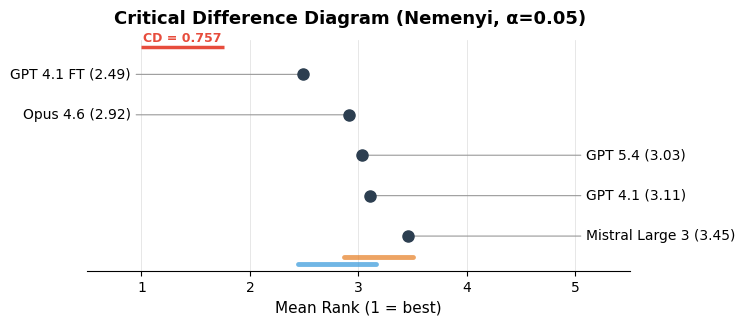

In [23]:
# ══════════════════════════════════════════════
# 6. VISUALIZZAZIONI
# ══════════════════════════════════════════════
# --- (a) Critical Difference Diagram ---
#fig, ax_cd = plt.subplots(figsize=(14*2/3, 0.3*len(list(combinations(range(K), 2)))), layout="constrained")
fig, ax_cd = plt.subplots(figsize=(7, 3))
 
fig.suptitle("Critical Difference Diagram (Nemenyi, α=0.05)", fontsize=13, fontweight="bold")
 
sorted_idx = np.argsort(mean_ranks)
y_positions = np.linspace(0.85, 0.15, K)
rank_min, rank_max = 1, K
margin = 0.5
 
ax_cd.set_xlim(rank_min - margin, rank_max + margin)
ax_cd.set_ylim(0, 1)
ax_cd.set_xlabel("Mean Rank (1 = best)", fontsize=11)
 
# Asse dei ranghi in alto
for r in range(1, K + 1):
    ax_cd.axvline(r, color="#DDDDDD", linewidth=0.5, zorder=0)
 
# Segmento CD in alto
cd_y = 0.97
ax_cd.plot([1, 1 + CD], [cd_y, cd_y], color="#E74C3C", linewidth=2.5, solid_capstyle="butt")
ax_cd.text(1 + CD / 2, cd_y + 0.02, f"CD = {CD:.3f}", ha="center", fontsize=9,
           color="#E74C3C", fontweight="bold")
 
# Modelli
for k, idx in enumerate(sorted_idx):
    r = mean_ranks[idx]
    y = y_positions[k]
    ax_cd.plot(r, y, "o", color="#2C3E50", markersize=8, zorder=5)
    label_x = rank_min - 0.1 if r <= (rank_min + rank_max) / 2 else rank_max + 0.1
    ha = "right" if label_x < r else "left"
    ax_cd.annotate(f"{scores.columns[idx]} ({r:.2f})", xy=(r, y), xytext=(label_x, y),
                   fontsize=10, ha=ha, va="center",
                   arrowprops=dict(arrowstyle="-", color="#999999", lw=0.8))
 
# Barre orizzontali per gruppi non significativi (cliques)
# Identifica cliques: gruppi di modelli la cui differenza di rango < CD
cliques = []
for i in range(K):
    for j in range(i + 1, K):
        si, sj = sorted_idx[i], sorted_idx[j]
        if abs(mean_ranks[si] - mean_ranks[sj]) < CD:
            # Cerca se estendere una clique esistente
            merged = False
            for c in cliques:
                if si in c or sj in c:
                    c.add(si)
                    c.add(sj)
                    merged = True
                    break
            if not merged:
                cliques.append({si, sj})
  
# Merge overlapping cliques
merged_cliques = []
for c in cliques:
    added = False
    for mc in merged_cliques:
        if mc & c:
            mc |= c
            added = True
            break
    if not added:
        merged_cliques.append(c.copy())
         
# Valida: rimuovi coppie all'interno di cliques che sono significative
final_cliques = []
for c in merged_cliques:
    members = sorted(c, key=lambda x: mean_ranks[x])
    # Verifica che TUTTE le coppie nella clique siano non significative
    valid = True
    for a, b in combinations(members, 2):
        if abs(mean_ranks[a] - mean_ranks[b]) >= CD:
            valid = False
            break
    if valid:
        final_cliques.append(members)
    else:
        # Prova sotto-cliques
        for size in range(len(members), 1, -1):
            for sub in combinations(members, size):
                sub_valid = all(
                    abs(mean_ranks[a] - mean_ranks[b]) < CD
                    for a, b in combinations(sub, 2)
                )
                if sub_valid and not any(set(sub) <= set(fc) for fc in final_cliques):
                    final_cliques.append(list(sub))
 
bar_colors = ["#3498DB", "#E67E22", "#2ECC71", "#9B59B6", "#E74C3C"]
for ci, clique in enumerate(final_cliques):
    r_vals = [mean_ranks[m] for m in clique]
    bar_y = 0.03 + ci * 0.03
    ax_cd.plot([min(r_vals) - 0.05, max(r_vals) + 0.05], [bar_y, bar_y],
               color=bar_colors[ci % len(bar_colors)], linewidth=3.5,
               solid_capstyle="round", alpha=0.7)
 
ax_cd.spines["top"].set_visible(False)
ax_cd.spines["right"].set_visible(False)
ax_cd.spines["left"].set_visible(False)
ax_cd.set_yticks([])

if SAVE_FIG:
    plt.savefig(f"../figures/{FIGURES_NAME}_critical_difference.png", dpi=150, bbox_inches="tight")
plt.show()

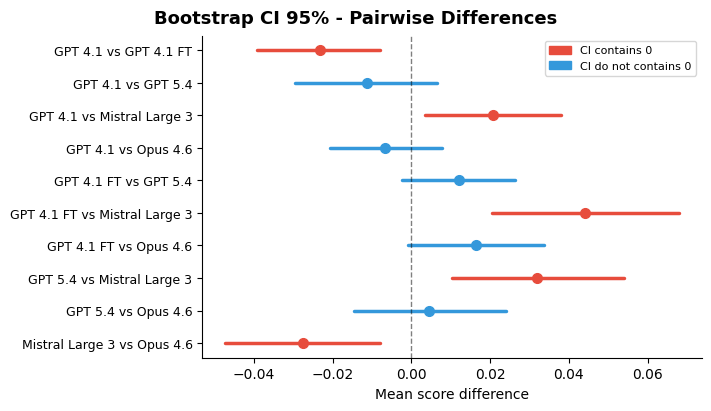

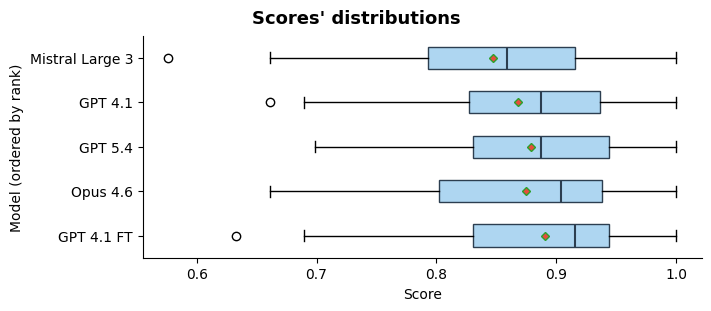

In [24]:
# --- (b) Bootstrap CI plot ---
#fig, ax_boot = plt.subplots(figsize=(14*2/3, len(list(combinations(range(K), 2)))*4/3), layout="constrained")
fig, ax_boot = plt.subplots(figsize=(7, 4), layout="constrained")

fig.suptitle("Bootstrap CI 95% - Pairwise Differences", fontsize=13, fontweight="bold")
#ax_boot.set_title("Bootstrap CI 95% - Pairwise Differences", fontsize=13, fontweight="bold")
 
pair_labels = []
y_pos = []
for idx, (i, j) in enumerate(combinations(range(K), 2)):
    res = boot_results[(i, j)]
    y = idx
    color = "#E74C3C" if not (res["ci_lo"] <= 0 <= res["ci_hi"]) else "#3498DB"
    ax_boot.plot([res["ci_lo"], res["ci_hi"]], [y, y], color=color, linewidth=2.5,
                 solid_capstyle="round")
    ax_boot.plot(res["diff"], y, "o", color=color, markersize=7, zorder=5)
    pair_labels.append(f"{scores.columns[i]} vs {scores.columns[j]}")
    y_pos.append(y)
 
ax_boot.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax_boot.set_yticks(y_pos)
ax_boot.set_yticklabels(pair_labels, fontsize=9)
ax_boot.set_xlabel("Mean score difference")
ax_boot.invert_yaxis()
ax_boot.spines["top"].set_visible(False)
ax_boot.spines["right"].set_visible(False)
 
red_patch = mpatches.Patch(color="#E74C3C", label="CI contains 0")
blue_patch = mpatches.Patch(color="#3498DB", label="CI do not contains 0")
ax_boot.legend(handles=[red_patch, blue_patch], fontsize=8, loc="best")

if SAVE_FIG:
    plt.savefig(f"../figures/{FIGURES_NAME}_bootstrap_ci.png", dpi=150, bbox_inches="tight")
plt.show()


# --- (c) Distribuzione score per modello ---
#fig, ax_box = plt.subplots(figsize=(14*2/3, K*4/3), layout="constrained")
fig, ax_box = plt.subplots(figsize=(7, 3), layout="constrained")

#ax_box.set_title("Scores' distributions", fontsize=13, fontweight="bold")
fig.suptitle("Scores' distributions", fontsize=13, fontweight="bold")
 
bp = ax_box.boxplot([scores.iloc[:, j] for j in order], tick_labels=[scores.columns[j] for j in order],
                    patch_artist=True, showmeans=True,
                    meanprops=dict(marker="D", markerfacecolor="#E74C3C", markersize=4),
                    medianprops=dict(color="#2C3E50", linewidth=1.5), orientation="horizontal")
 
#box_colors = ["#AED6F1", "#A9DFBF", "#F9E79F", "#F5CBA7", "#D7BDE2"]
#for patch, color in zip(bp["boxes"], box_colors):
for patch in bp["boxes"]:
#    patch.set_facecolor(color)
    patch.set_facecolor("#AED6F1")
    patch.set_edgecolor("#2C3E50")
 
ax_box.set_xlabel("Score")
ax_box.set_ylabel("Model (ordered by rank)")
ax_box.spines["top"].set_visible(False)
ax_box.spines["right"].set_visible(False)

if SAVE_FIG:
    plt.savefig(f"../figures/{FIGURES_NAME}_boxplot_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

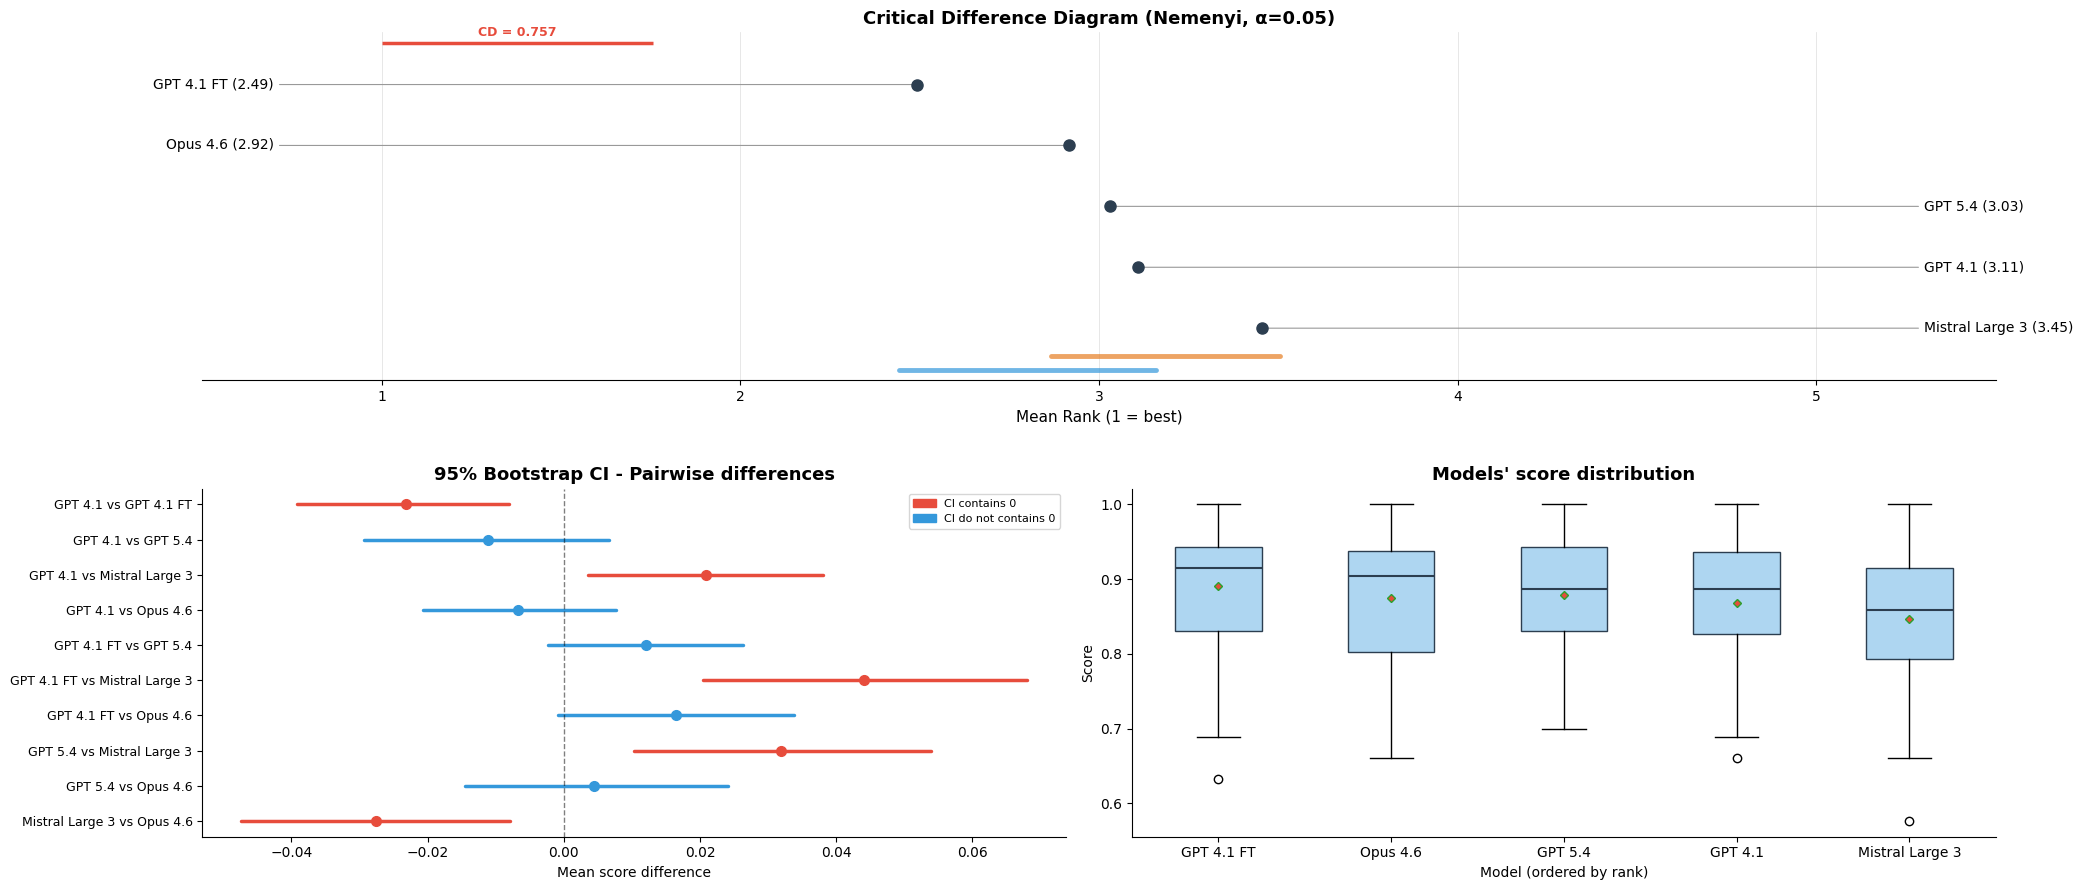


RIEPILOGO
  Friedman p-value: 0.007025
  Coppie significative (Nemenyi):      1/10
  Coppie significative (Permutazione):  5/10
  Coppie significative (Bootstrap CI):  5/10

  Classifica per rango medio:
    1. GPT 4.1 FT   (rango 2.49, media score 0.8909)
    2. Opus 4.6     (rango 2.92, media score 0.8744)
    3. GPT 5.4      (rango 3.03, media score 0.8788)
    4. GPT 4.1      (rango 3.11, media score 0.8677)
    5. Mistral Large 3 (rango 3.45, media score 0.8469)


In [ ]:
# ══════════════════════════════════════════════
# 6. VISUALIZZAZIONI
# ══════════════════════════════════════════════
fig = plt.figure(figsize=(21, 9))
 
# --- (a) Critical Difference Diagram ---
ax_cd = fig.add_subplot(2, 2, (1, 2))
ax_cd.set_title("Critical Difference Diagram (Nemenyi, α=0.05)", fontsize=13, fontweight="bold")
 
sorted_idx = np.argsort(mean_ranks)
y_positions = np.linspace(0.85, 0.15, K)
rank_min, rank_max = 1, K
margin = 0.5
 
ax_cd.set_xlim(rank_min - margin, rank_max + margin)
ax_cd.set_ylim(0, 1)
ax_cd.set_xlabel("Mean Rank (1 = best)", fontsize=11)
 
# Asse dei ranghi in alto
for r in range(1, K + 1):
    ax_cd.axvline(r, color="#DDDDDD", linewidth=0.5, zorder=0)
 
# Segmento CD in alto
cd_y = 0.97
ax_cd.plot([1, 1 + CD], [cd_y, cd_y], color="#E74C3C", linewidth=2.5, solid_capstyle="butt")
ax_cd.text(1 + CD / 2, cd_y + 0.02, f"CD = {CD:.3f}", ha="center", fontsize=9,
           color="#E74C3C", fontweight="bold")
 
# Modelli
for k, idx in enumerate(sorted_idx):
    r = mean_ranks[idx]
    y = y_positions[k]
    ax_cd.plot(r, y, "o", color="#2C3E50", markersize=8, zorder=5)
    label_x = rank_min - 0.3 if r <= (rank_min + rank_max) / 2 else rank_max + 0.3
    ha = "right" if label_x < r else "left"
    ax_cd.annotate(f"{scores.columns[idx]} ({r:.2f})", xy=(r, y), xytext=(label_x, y),
                   fontsize=10, ha=ha, va="center",
                   arrowprops=dict(arrowstyle="-", color="#999999", lw=0.8))
 
# Barre orizzontali per gruppi non significativi (cliques)
# Identifica cliques: gruppi di modelli la cui differenza di rango < CD
cliques = []
for i in range(K):
    for j in range(i + 1, K):
        si, sj = sorted_idx[i], sorted_idx[j]
        if abs(mean_ranks[si] - mean_ranks[sj]) < CD:
            # Cerca se estendere una clique esistente
            merged = False
            for c in cliques:
                if si in c or sj in c:
                    c.add(si)
                    c.add(sj)
                    merged = True
                    break
            if not merged:
                cliques.append({si, sj})
 
# Merge overlapping cliques
merged_cliques = []
for c in cliques:
    added = False
    for mc in merged_cliques:
        if mc & c:
            mc |= c
            added = True
            break
    if not added:
        merged_cliques.append(c.copy())
 
# Valida: rimuovi coppie all'interno di cliques che sono significative
final_cliques = []
for c in merged_cliques:
    members = sorted(c, key=lambda x: mean_ranks[x])
    # Verifica che TUTTE le coppie nella clique siano non significative
    valid = True
    for a, b in combinations(members, 2):
        if abs(mean_ranks[a] - mean_ranks[b]) >= CD:
            valid = False
            break
    if valid:
        final_cliques.append(members)
    else:
        # Prova sotto-cliques
        for size in range(len(members), 1, -1):
            for sub in combinations(members, size):
                sub_valid = all(
                    abs(mean_ranks[a] - mean_ranks[b]) < CD
                    for a, b in combinations(sub, 2)
                )
                if sub_valid and not any(set(sub) <= set(fc) for fc in final_cliques):
                    final_cliques.append(list(sub))
 
bar_colors = ["#3498DB", "#E67E22", "#2ECC71", "#9B59B6", "#E74C3C"]
for ci, clique in enumerate(final_cliques):
    r_vals = [mean_ranks[m] for m in clique]
    bar_y = 0.03 + ci * 0.04
    ax_cd.plot([min(r_vals) - 0.05, max(r_vals) + 0.05], [bar_y, bar_y],
               color=bar_colors[ci % len(bar_colors)], linewidth=3.5,
               solid_capstyle="round", alpha=0.7)
 
ax_cd.spines["top"].set_visible(False)
ax_cd.spines["right"].set_visible(False)
ax_cd.spines["left"].set_visible(False)
ax_cd.set_yticks([])

# --- (b) Bootstrap CI plot ---

ax_boot = fig.add_subplot(2, 2, 3)
ax_boot.set_title("95% Bootstrap CI - Pairwise differences", fontsize=13, fontweight="bold")
 
pair_labels = []
y_pos = []
for idx, (i, j) in enumerate(combinations(range(K), 2)):
    res = boot_results[(i, j)]
    y = idx
    color = "#E74C3C" if not (res["ci_lo"] <= 0 <= res["ci_hi"]) else "#3498DB"
    ax_boot.plot([res["ci_lo"], res["ci_hi"]], [y, y], color=color, linewidth=2.5,
                 solid_capstyle="round")
    ax_boot.plot(res["diff"], y, "o", color=color, markersize=7, zorder=5)
    pair_labels.append(f"{scores.columns[i]} vs {scores.columns[j]}")
    y_pos.append(y)
 
ax_boot.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax_boot.set_yticks(y_pos)
ax_boot.set_yticklabels(pair_labels, fontsize=9)
ax_boot.set_xlabel("Mean score difference")
ax_boot.invert_yaxis()
ax_boot.spines["top"].set_visible(False)
ax_boot.spines["right"].set_visible(False)
 
red_patch = mpatches.Patch(color="#E74C3C", label="CI contains 0")
blue_patch = mpatches.Patch(color="#3498DB", label="CI do not contains 0")
ax_boot.legend(handles=[red_patch, blue_patch], fontsize=8, loc="best")


# --- (c) Distribuzione score per modello ---
ax_box = fig.add_subplot(2, 2, 4)
ax_box.set_title("Models' score distribution", fontsize=13, fontweight="bold")
 
bp = ax_box.boxplot([scores.iloc[:, j] for j in order], tick_labels=[scores.columns[j] for j in order],
                    patch_artist=True, showmeans=True,
                    meanprops=dict(marker="D", markerfacecolor="#E74C3C", markersize=4),
                    medianprops=dict(color="#2C3E50", linewidth=1.5))
 
#box_colors = ["#AED6F1", "#A9DFBF", "#F9E79F", "#F5CBA7", "#D7BDE2"]
#for patch, color in zip(bp["boxes"], box_colors):
for patch in bp["boxes"]:
#    patch.set_facecolor(color)
    patch.set_facecolor("#AED6F1")
    patch.set_edgecolor("#2C3E50")
 
ax_box.set_ylabel("Score")
ax_box.set_xlabel("Model (ordered by rank)")
ax_box.spines["top"].set_visible(False)
ax_box.spines["right"].set_visible(False)
 
 
###############################
# SALVATAGGIO 
###############################
 
plt.tight_layout(h_pad=3)

if SAVE_FIG:
    plt.savefig(f"../figures/{FIGURES_NAME}_complete.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
 
print()
print("=" * 65)
print("RIEPILOGO")
print("=" * 65)
print(f"  Friedman p-value: {p_friedman:.6f}")
if p_friedman < 0.05:
    sig_pairs_nem = [(i, j) for (i, j), v in nemenyi_results.items() if v["sig"]]
    sig_pairs_perm = [(i, j) for (i, j), v in perm_pvalues_bh.items() if v < 0.05]
    sig_pairs_boot = [(i, j) for (i, j), v in boot_results.items()
                      if not (v["ci_lo"] <= 0 <= v["ci_hi"])]
    print(f"  Coppie significative (Nemenyi):      {len(sig_pairs_nem)}/10")
    print(f"  Coppie significative (Permutazione):  {len(sig_pairs_perm)}/10")
    print(f"  Coppie significative (Bootstrap CI):  {len(sig_pairs_boot)}/10")
    print()
    print(f"  Classifica per rango medio:")
    for rank, idx in enumerate(order, 1):
        print(f"    {rank}. {scores.columns[idx]:<12} (rango {mean_ranks[idx]:.2f}, "
              f"media score {scores.iloc[:, idx].mean():.4f})")
else:
    print("  Nessuna differenza significativa rilevata tra i modelli.")
    print(f"  Con N={N}, la potenza statistica potrebbe essere insufficiente")
    print("  per rilevare differenze piccole. Valuta gli intervalli di confidenza.")